In [ ]:
# ===========================================
# Exploratory Data Analysis (EDA) - Crime Data
# Student: Monther alzoubi
# ===========================================

print("EDA Notebook Started Successfully ✔️")


EDA Notebook Started Successfully ✔️


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. IMPORT ALL REQUIRED LIBRARIES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
project_path = "/content/drive/MyDrive/Crime_Project"
data_path = os.path.join(project_path, "data")

print("Project folder:", project_path)
print("-" * 60)
try:
    items = os.listdir(project_path)
    if len(items) == 0:
        print("Project folder is empty.")
    else:
        print("Contents of project folder:")
        for item in items:
            print(" -", item)
except FileNotFoundError:
    print("Error: Project folder not found.")

print("\nData folder:", data_path)
print("-" * 60)
try:
    data_items = os.listdir(data_path)
    if len(data_items) == 0:
        print("Data folder is empty.")
    else:
        print("Contents of data folder:")
        for item in data_items:
            print(" -", item)
except FileNotFoundError:
    print("Error: Data folder not found.")

Project folder: /content/drive/MyDrive/Crime_Project
------------------------------------------------------------
Contents of project folder:
 - data

Data folder: /content/drive/MyDrive/Crime_Project/data
------------------------------------------------------------
Contents of data folder:
 - Crime_Data_from_2020_to_Present.xlsx
 - Crime_Data_from_2020_to_Present.csv


In [ ]:
# ------------------------------------------------------------
# 4. LOAD DATASET
# ------------------------------------------------------------

In [ ]:
csv_file_name = "Crime_Data_from_2020_to_Present.csv"
file_path = os.path.join(data_path, csv_file_name)

df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1004991, 28)


In [ ]:
# ------------------------------------------------------------
# 5. BASIC OVERVIEW
# ------------------------------------------------------------

In [ ]:
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

print("\nRandom Sample:")
print(df.sample(5, random_state=42))


Column Names:
['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']

Data Types:
DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
L

In [ ]:
# ------------------------------------------------------------
# 6. MISSING VALUES ANALYSIS
# ------------------------------------------------------------

Missing Values Summary:


,Missing Count,Missing %
Crm Cd 4,1004927,99.99
Crm Cd 3,1002677,99.77
Crm Cd 2,935831,93.12
Cross Street,850755,84.65
Weapon Used Cd,677744,67.44
Weapon Desc,677744,67.44
Mocodes,151619,15.09
Vict Descent,144656,14.39
Vict Sex,144644,14.39
Premis Desc,588,0.06


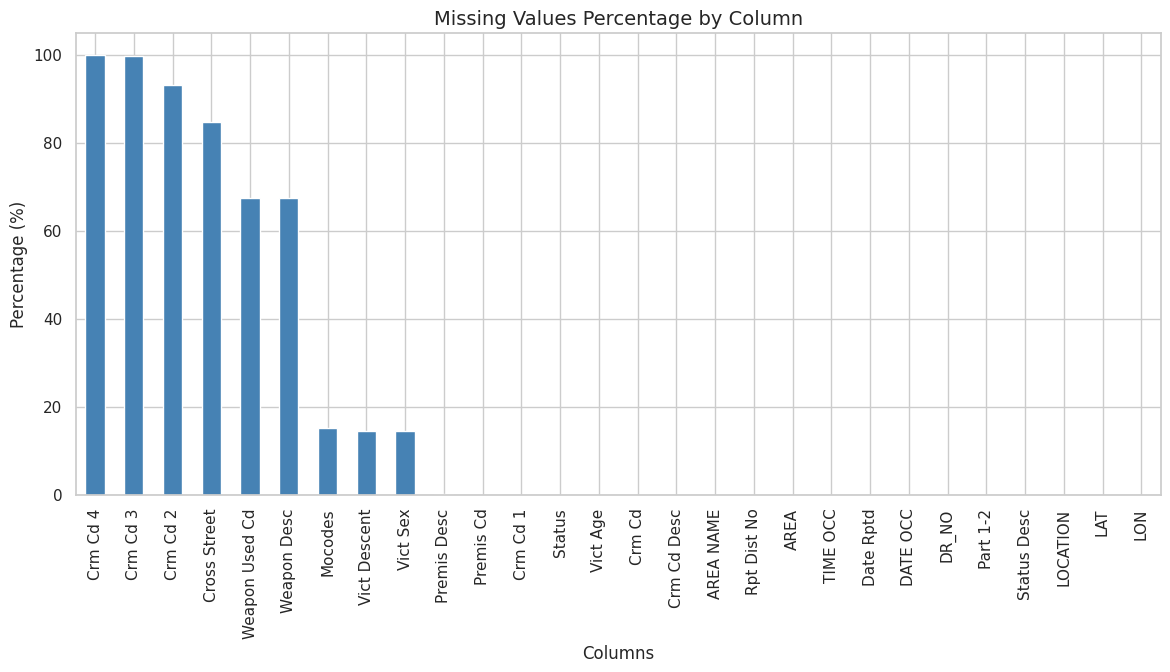

In [ ]:
# Missing values (count)
missing_values = df.isnull().sum().sort_values(ascending=False)

# Missing values (percentage)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

# Combine into one professional summary table
missing_table = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percentage.round(2)
})

print("Missing Values Summary:")
display(missing_table)

# Plot missing values percentage
plt.figure(figsize=(14,6))
missing_percentage.plot(kind='bar', color='steelblue')
plt.title("Missing Values Percentage by Column", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.show()


“The dataset contained high missingness in the secondary crime code fields (Crm Cd 2–4), weapon description fields, and cross-street information. These fields were either removed (for near-total missingness) or retained for descriptive purposes only. Moderate missingness was found in victim demographics (sex and descent), which were handled using categorical imputation. Core analytical fields such as crime type, date, time, area, and coordinates contained no missing values and were used directly in EDA and modeling.”

In [ ]:
# ------------------------------------------------------------
# 7. Duplicate Records Analysis
# ------------------------------------------------------------

In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")

# Show example duplicates (if any)
if duplicate_count > 0:
    print("\nSample Duplicate Rows:")
    display(df[df.duplicated()].head())
else:
    print("\nNo exact duplicate rows found.")

# Optional: Count duplicate DR_NO (incident number)
duplicate_drno = df.duplicated(subset=['DR_NO']).sum()
print(f"\nNumber of Duplicate DR_NO (Incident IDs): {duplicate_drno}")

if duplicate_drno > 0:
    print("\nSample Duplicate DR_NO Rows:")
    display(df[df.duplicated(subset=['DR_NO'])].head())

Number of Duplicate Rows: 0

No exact duplicate rows found.

Number of Duplicate DR_NO (Incident IDs): 0


Duplicate analysis revealed that the dataset contains no exact duplicate rows. This indicates consistent data entry and high data integrity in the original source.

In [ ]:
# ------------------------------------------------------------
# 8. NUMERIC SUMMARY
# ------------------------------------------------------------


Numeric Columns: ['DR_NO', 'TIME OCC', 'AREA', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Vict Age', 'Premis Cd', 'Weapon Used Cd', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LAT', 'LON']

Numeric Summary:
                    count          mean           std       min           25%  \
DR_NO           1004991.0  2.202215e+08  1.319718e+07  817.0000  2.106169e+08   
TIME OCC        1004991.0  1.339900e+03  6.510613e+02    1.0000  9.000000e+02   
AREA            1004991.0  1.069174e+01  6.110255e+00    1.0000  5.000000e+00   
Rpt Dist No     1004991.0  1.115633e+03  6.111605e+02  101.0000  5.870000e+02   
Part 1-2        1004991.0  1.400348e+00  4.899691e-01    1.0000  1.000000e+00   
Crm Cd          1004991.0  5.001568e+02  2.052731e+02  110.0000  3.310000e+02   
Vict Age        1004991.0  2.891706e+01  2.199272e+01   -4.0000  0.000000e+00   
Premis Cd       1004975.0  3.056201e+02  2.193021e+02  101.0000  1.010000e+02   
Weapon Used Cd   327247.0  3.639553e+02  1.237345e+02  101.0000

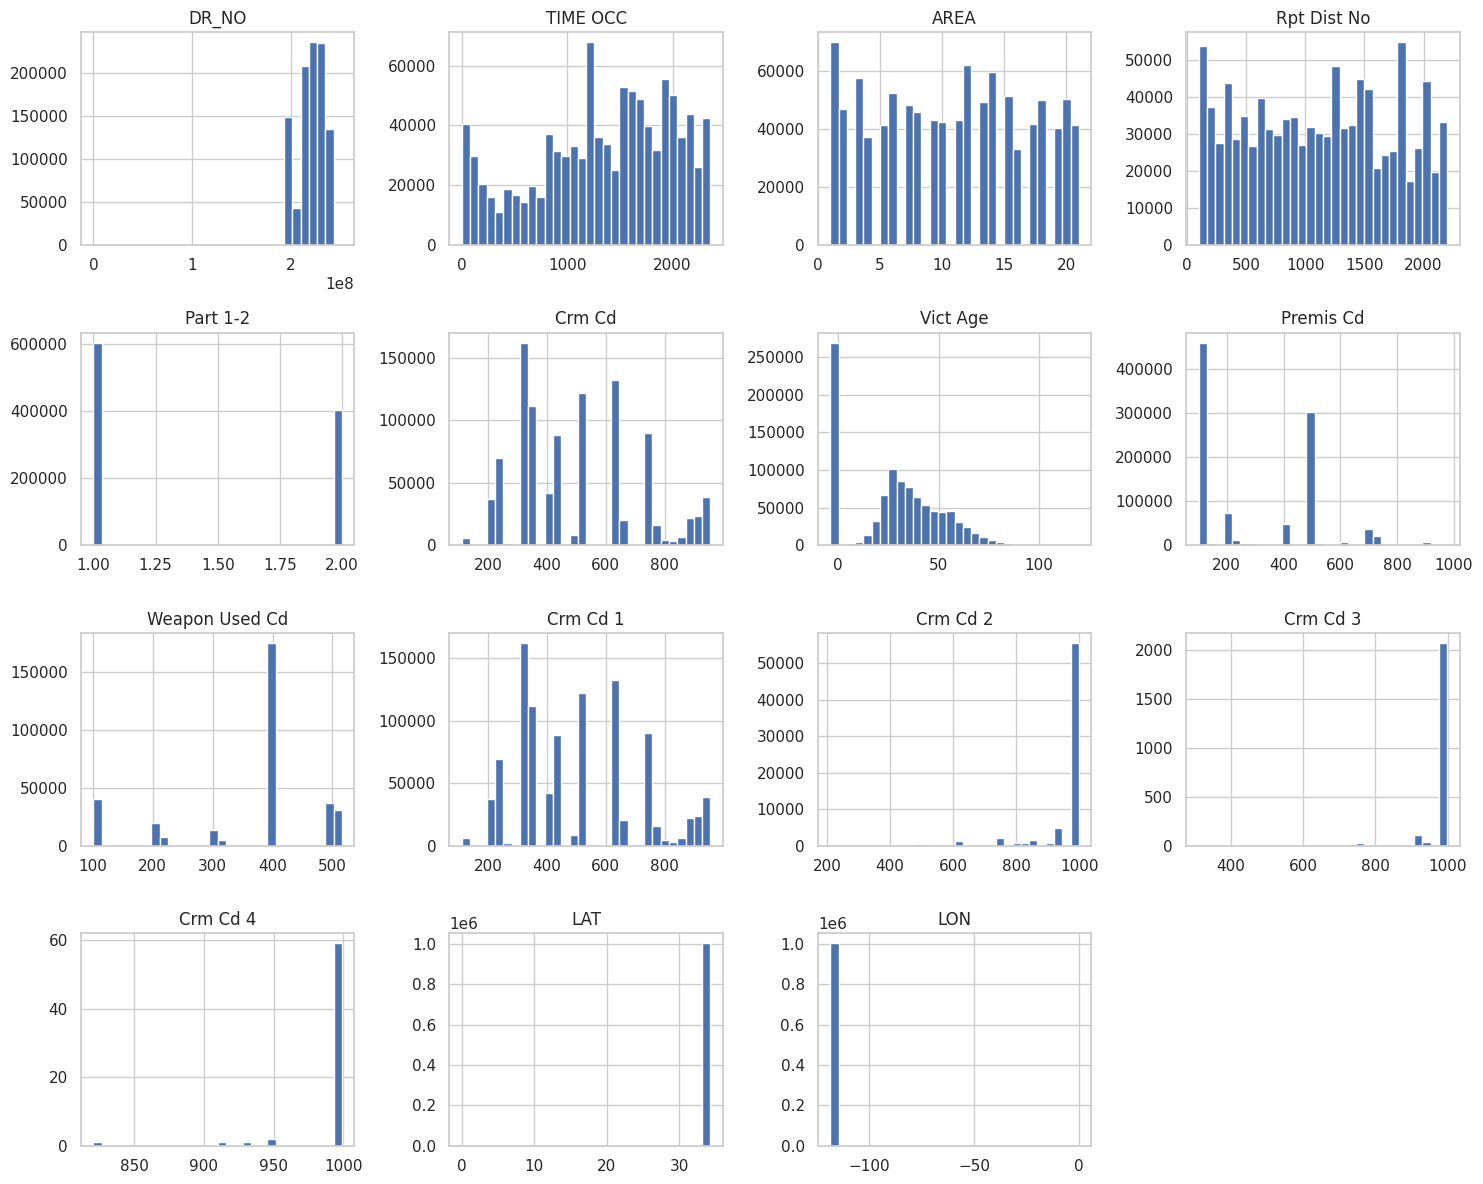

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumeric Columns:", list(numeric_cols))

print("\nNumeric Summary:")
print(df[numeric_cols].describe().T)

df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 9. CATEGORICAL SUMMARY
# ------------------------------------------------------------

Categorical Summary of Object Columns:



,count,unique,top,freq
Date Rptd,1004991,1896,02/02/2023 12:00:00 AM,929
DATE OCC,1004991,1879,01/01/2020 12:00:00 AM,1164
AREA NAME,1004991,21,Central,69670
Crm Cd Desc,1004991,140,VEHICLE - STOLEN,115190
Mocodes,853372,310940,0344,42187
Vict Sex,860347,5,M,403879
Vict Descent,860335,20,H,296404
Premis Desc,1004403,306,STREET,261284
Weapon Desc,327247,79,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",174761
Status,1004990,6,IC,802862



Top 10 Crime Types:


,count
Crm Cd Desc,
VEHICLE - STOLEN,115190
BATTERY - SIMPLE ASSAULT,74839
BURGLARY FROM VEHICLE,63517
THEFT OF IDENTITY,62537
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",61092
BURGLARY,57871
THEFT PLAIN - PETTY ($950 & UNDER),53717
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",53525
INTIMATE PARTNER - SIMPLE ASSAULT,46712


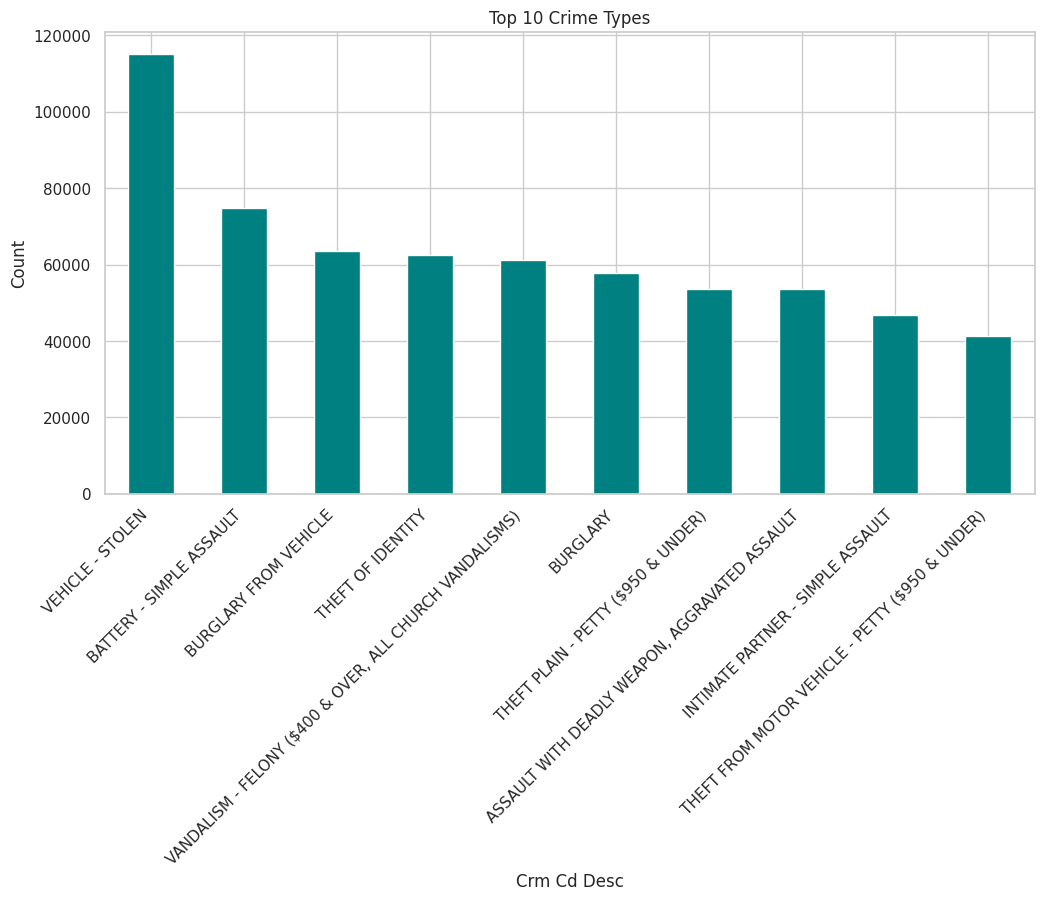


Top Areas (AREA NAME):


,count
AREA NAME,
Central,69670
77th Street,61758
Pacific,59514
Southwest,57441
Hollywood,52429
N Hollywood,51107
Olympic,50071
Southeast,49936
Newton,49177


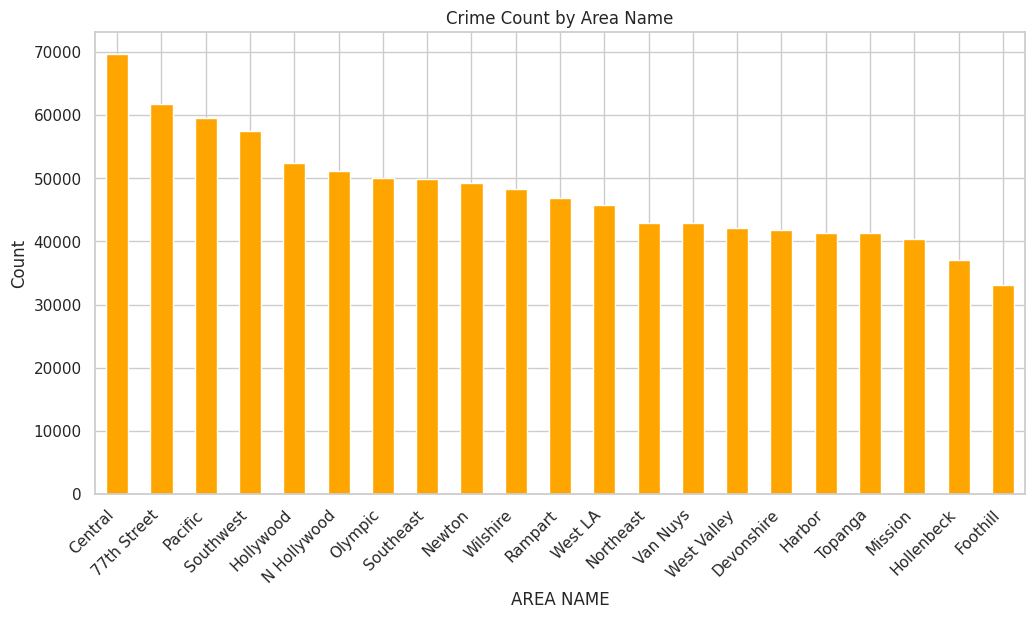


Victim Sex Distribution:


,count
Vict Sex,
M,403879
F,358580
X,97773
H,114
-,1


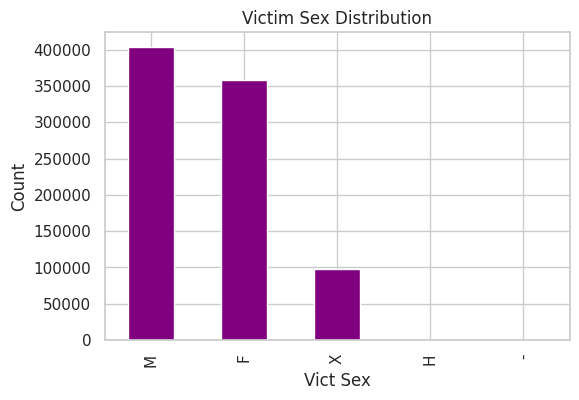


Victim Descent Distribution:


,count
Vict Descent,
H,296404
W,201442
B,135816
X,106685
O,78005
A,21340
K,5990
F,4838
C,4631


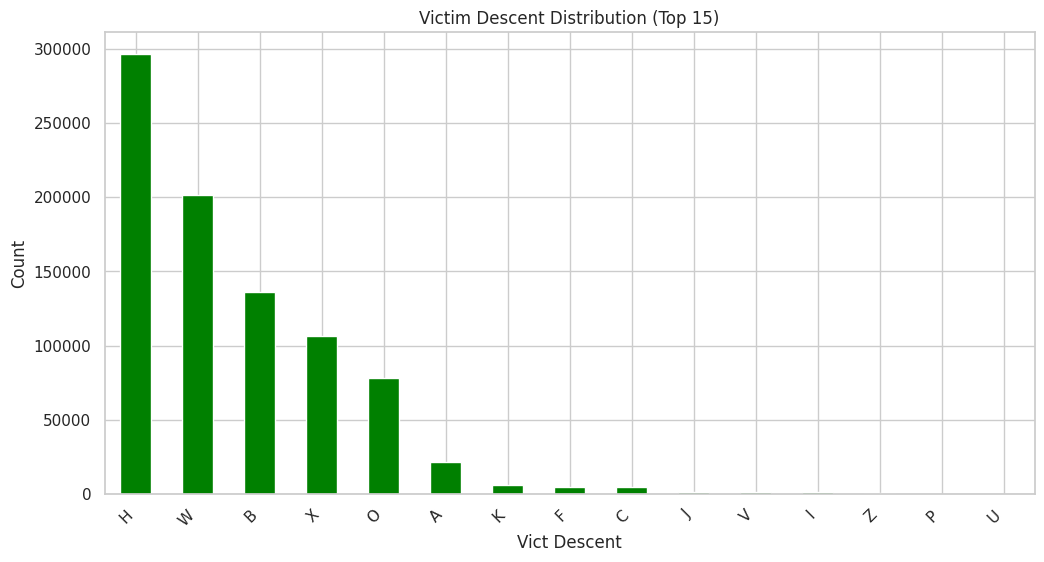


Top 10 Premises Descriptions:


,count
Premis Desc,
STREET,261284
SINGLE FAMILY DWELLING,163654
"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",119011
PARKING LOT,69147
OTHER BUSINESS,47647
SIDEWALK,40861
"VEHICLE, PASSENGER/TRUCK",29302
GARAGE/CARPORT,19362
DRIVEWAY,16082


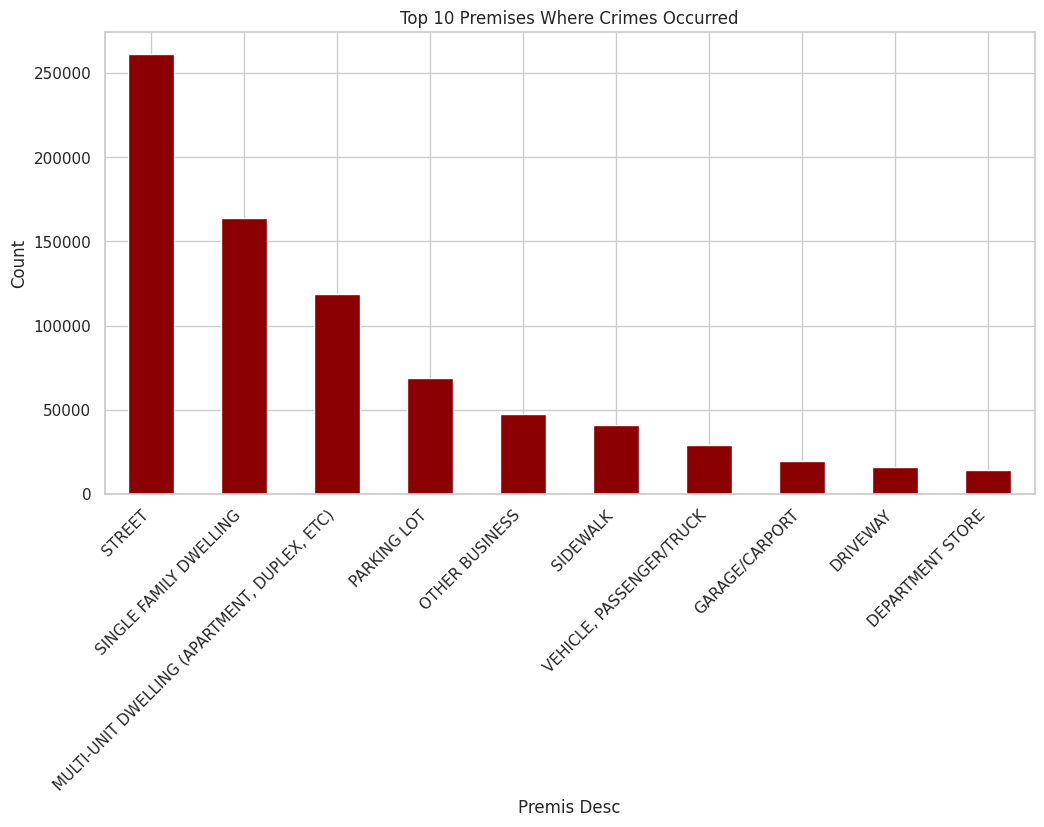


Crime Status Distribution:


,count
Status,
IC,802862
AO,109802
AA,87155
JA,3286
JO,1879
CC,6


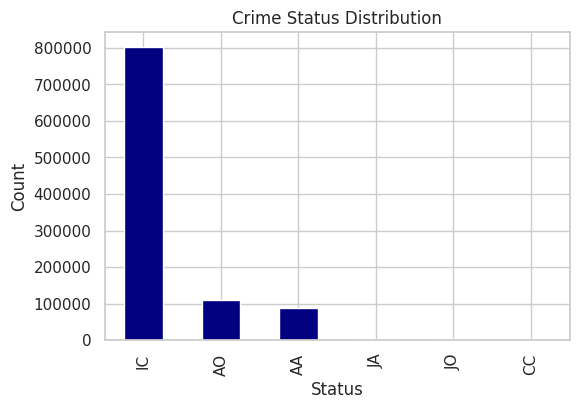

In [ ]:
print("Categorical Summary of Object Columns:\n")

# Summary of all object (categorical) columns
categorical_summary = df.describe(include=['object']).T
display(categorical_summary)
# Top Categories for Important Columns
# 1. Top 10 Crime Types
print("\nTop 10 Crime Types:")
display(df['Crm Cd Desc'].value_counts().head(10))

plt.figure(figsize=(12,6))
df['Crm Cd Desc'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Crime Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# 2. Most Common Areas
print("\nTop Areas (AREA NAME):")
display(df['AREA NAME'].value_counts().head(10))

plt.figure(figsize=(12,6))
df['AREA NAME'].value_counts().plot(kind='bar', color='orange')
plt.title("Crime Count by Area Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# 3. Victim Sex Distribution
print("\nVictim Sex Distribution:")
display(df['Vict Sex'].value_counts())

plt.figure(figsize=(6,4))
df['Vict Sex'].value_counts().plot(kind='bar', color='purple')
plt.title("Victim Sex Distribution")
plt.ylabel("Count")
plt.show()

# 4. Victim Descent Distribution
print("\nVictim Descent Distribution:")
display(df['Vict Descent'].value_counts().head(15))

plt.figure(figsize=(12,6))
df['Vict Descent'].value_counts().head(15).plot(kind='bar', color='green')
plt.title("Victim Descent Distribution (Top 15)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# 5. Premises Description (Where the crime occurred)
print("\nTop 10 Premises Descriptions:")
display(df['Premis Desc'].value_counts().head(10))

plt.figure(figsize=(12,6))
df['Premis Desc'].value_counts().head(10).plot(kind='bar', color='darkred')
plt.title("Top 10 Premises Where Crimes Occurred")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# 6. Crime Status (Solved, Arrest, Investigation)
print("\nCrime Status Distribution:")
display(df['Status'].value_counts())

plt.figure(figsize=(6,4))
df['Status'].value_counts().plot(kind='bar', color='navy')
plt.title("Crime Status Distribution")
plt.ylabel("Count")
plt.show()

1- The highest frequency crime category is Vehicle Theft, followed by Simple Assault and Burglary-related incidents. This indicates a strong emphasis on property crimes and vehicle-related offenses in the dataset.
2-Central Division has the highest crime volume, indicating dense urban activity. Divisions in South Los Angeles (77th Street, Southwest) also show elevated crime rates, reflecting known high-risk areas.
3- Male victims represent the largest proportion of incidents, followed closely by female victims. A significant portion (~10%) is classified as ‘Unknown’, likely due to incomplete reporting.
4- Victims of Hispanic descent represent the largest group, followed by White and Black individuals. A large number of ‘Unknown’ descent records indicate incomplete demographic reporting.
5- Most crimes occur outdoors, particularly on streets and sidewalks, followed by residential areas (single-family and multi-unit dwellings). Parking lots and business areas also show high incident frequencies.
6- Most incidents remain under investigation (IC), with a smaller portion resulting in adult or juvenile arrests. This indicates that a majority of cases may not lead to immediate resolution.
7-

In [ ]:
# ------------------------------------------------------------
# 10. CORRELATION ANALYSIS (HEATMAP)
# ------------------------------------------------------------

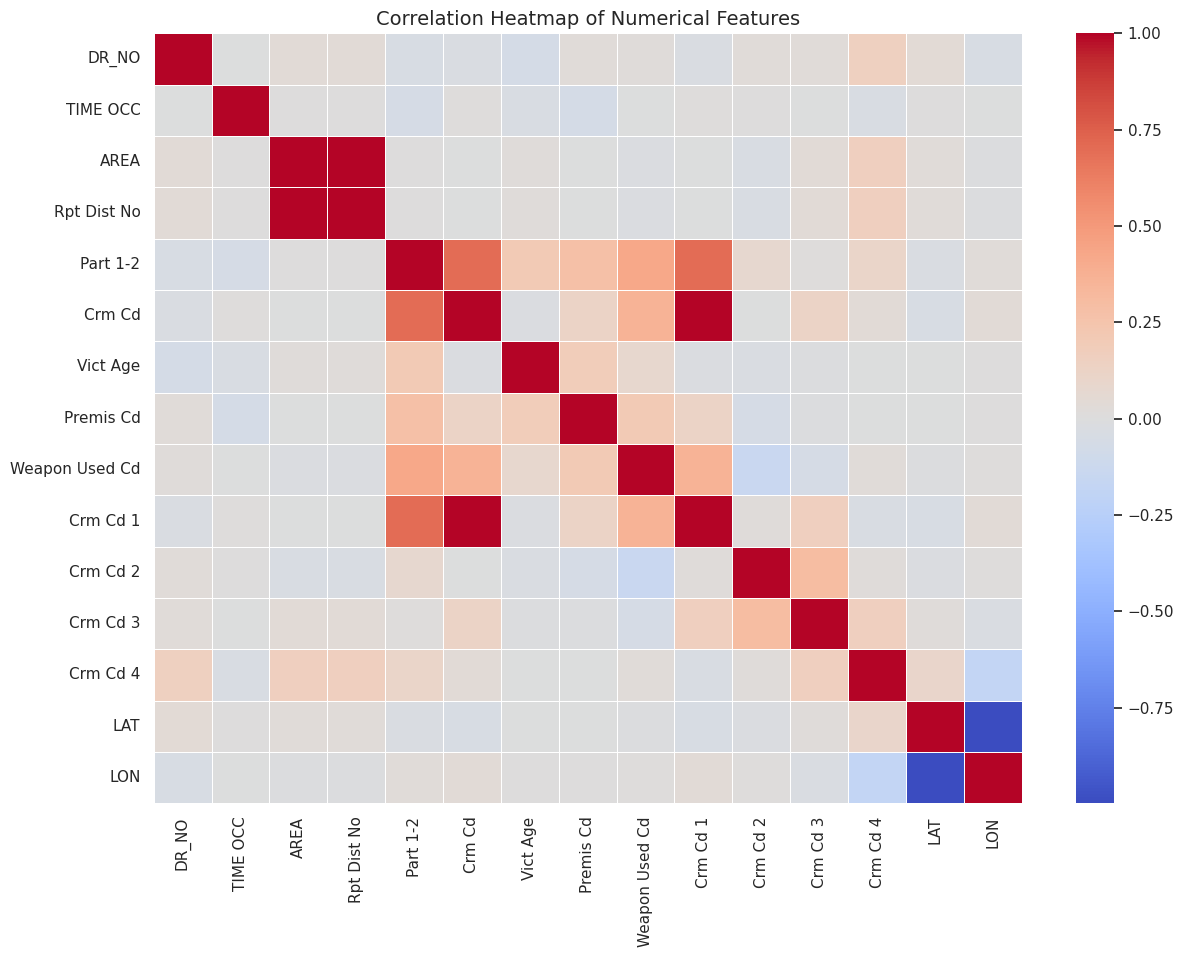

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

The correlation heatmap indicates that most numerical variables have weak relationships with one another, demonstrating that crime occurrences depend on diverse and independent factors. The strongest positive correlation is found between ‘Crm Cd’ and ‘Crm Cd 1’, as both represent the primary crime type. Moderate correlations appear between crime severity, weapon usage, and crime codes. Latitude and longitude show a strong negative correlation due to their geographic relationship. No problematic or unexpected correlations were detected.

In [ ]:
# ------------------------------------------------------------
# 12. DATA CLEANING & PREPROCESSING
# ------------------------------------------------------------

In [ ]:
# Work on a copy to keep the original raw data
df_clean = df.copy()

print("Original shape:", df_clean.shape)

# 1) Drop columns with extremely high missingness
cols_to_drop = ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
print("Dropped columns with ~100% missing:", cols_to_drop)

# 2) Remove invalid victim ages (negative or unrealistically high)
before_rows = df_clean.shape[0]
df_clean = df_clean[(df_clean['Vict Age'] >= 0) & (df_clean['Vict Age'] <= 100)]
after_rows = df_clean.shape[0]
print(f"Rows removed due to invalid Vict Age: {before_rows - after_rows}")

# 3) Remove invalid coordinates (longitude = 0)
before_rows = df_clean.shape[0]
df_clean = df_clean[df_clean['LON'] != 0]
after_rows = df_clean.shape[0]
print(f"Rows removed due to invalid LON = 0: {before_rows - after_rows}")

# 4) Convert date columns to datetime
df_clean['Date Rptd'] = pd.to_datetime(df_clean['Date Rptd'])
df_clean['DATE OCC'] = pd.to_datetime(df_clean['DATE OCC'])
print("Converted Date Rptd and DATE OCC to datetime.")

# 5) Create date-related features (report date & occurrence date)
df_clean['Rpt_Year'] = df_clean['Date Rptd'].dt.year
df_clean['Rpt_Month'] = df_clean['Date Rptd'].dt.month
df_clean['Rpt_Day'] = df_clean['Date Rptd'].dt.day

df_clean['Occ_Year'] = df_clean['DATE OCC'].dt.year
df_clean['Occ_Month'] = df_clean['DATE OCC'].dt.month
df_clean['Occ_Day'] = df_clean['DATE OCC'].dt.day

print("Created Rpt_Year/Month/Day and Occ_Year/Month/Day features.")

# 6) Extract hour from TIME OCC
df_clean['Hour'] = df_clean['TIME OCC'] // 100
print("Created Hour feature from TIME OCC.")

# 7) Handle missing values in important categorical columns
categorical_fill = {
    'Vict Sex': 'Unknown',
    'Vict Descent': 'Unknown',
    'Mocodes': 'Unknown'
}
df_clean = df_clean.fillna(value=categorical_fill)
df_clean['Premis Desc'] = df_clean['Premis Desc'].fillna('Unknown Premise')
df_clean['Premis Cd'] = df_clean['Premis Cd'].fillna(-1)
df_clean['Weapon Desc'] = df_clean['Weapon Desc'].fillna('No Weapon / Unknown')
df_clean['Weapon Used Cd'] = df_clean['Weapon Used Cd'].fillna(-1)
df_clean['Cross Street'] = df_clean['Cross Street'].fillna('Unknown')
print("Filled missing values in Vict Sex, Vict Descent, Mocodes, Premis Desc, Weapon fields, and Cross Street with appropriate placeholders (e.g., 'Unknown', 'No Weapon', -1).")


# 8) Reset index after row removals
df_clean.reset_index(drop=True, inplace=True)

print("\nCleaning complete.")
print("Cleaned shape:", df_clean.shape)
df_clean.info()

Original shape: (1004991, 28)
Dropped columns with ~100% missing: ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']
Rows removed due to invalid Vict Age: 138
Rows removed due to invalid LON = 0: 2240
Converted Date Rptd and DATE OCC to datetime.
Created Rpt_Year/Month/Day and Occ_Year/Month/Day features.
Created Hour feature from TIME OCC.
Filled missing values in Vict Sex, Vict Descent, Mocodes, Premis Desc, Weapon fields, and Cross Street with appropriate placeholders (e.g., 'Unknown', 'No Weapon', -1).

Cleaning complete.
Cleaned shape: (1002613, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002613 entries, 0 to 1002612
Data columns (total 32 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   DR_NO           1002613 non-null  int64         
 1   Date Rptd       1002613 non-null  datetime64[ns]
 2   DATE OCC        1002613 non-null  datetime64[ns]
 3   TIME OCC        1002613 non-null  int64         
 4   AREA       

<h3>Step 12 – Data Cleaning Summary</h3>
<p>
We identified and fixed the main data quality issues in the crime dataset.
Invalid victim ages and incorrect coordinates were removed, date columns were converted
to proper datetime format, and missing values in key categorical fields were filled with
appropriate placeholders (e.g., "Unknown", "No Weapon", -1). The cleaned dataset is now
consistent, complete, and ready for final EDA and predictive modeling.
</p>


In [ ]:
#Save a local copy inside Colab files
#df_clean.to_csv('/content/cleaned_crime_data1.csv', index=False)
#print(" Cleaned dataset saved in Colab: /content/cleaned_crime_data1.csv")

 Cleaned dataset saved in Colab: /content/cleaned_crime_data.csv
